In [1]:
"""
"""

import os, time
from pathlib import Path
import geopandas as gpd
import pandas as pd
import osmnx as ox

from tqdm.notebook import tqdm

# --- Settings for OSMNX
ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.requests_timeout = 500  # seconds

# main local directory for data
datadir = '/Users/mcc/Library/CloudStorage/Box-Box/MCC/data'

# use the current working directory for the project
projdir = Path.cwd().parents[1] # moves up two, outside code directory
print(f"Project directory set to: {projdir}")

proj_crs = 26913  # NAD83 UTM Zone 13N

print("Ready to go!")

Project directory set to: /Users/mcc/Library/CloudStorage/Box-Box/MCC/projects
Ready to go!


Found 33 counties


<Axes: >

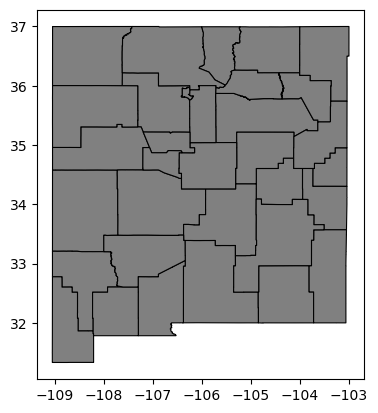

In [2]:
# --- Load county boundaries
fp = os.path.join(datadir, 'boundaries/political/TIGER/tl_2024_us_county/tl_2024_us_county.shp')
counties = gpd.read_file(fp).to_crs(proj_crs)

# --- Filter to New Mexico
counties = counties[counties['STATEFP'] == '35']
print(f"Found {len(counties)} counties")
counties.to_crs(4326).plot(
    facecolor="grey", edgecolor="black",
    linewidth=0.8, zorder=1,
)

In [3]:
# --- Define the road feature query
road_features = [
    'primary','secondary','tertiary','residential',
    'service','motorway','trunk','track','unclassified'
]

In [4]:
start = time.time()

# --- Define the road feature query
road_features = [
    'primary','secondary','tertiary','residential',
    'service','motorway','trunk','track','unclassified'
]

def is_keep(road_tag):
    if isinstance(road_tag, list):
        return any(tag in roads_keep for tag in road_tag)
    elif isinstance(road_tag, str):
        return road_tag in roads_keep
    else:
        return False

def flatten_highway(val):
    """Flattens list objects in the 'highway' tag"""
    if isinstance(val, list):  # multiple tags (e.g., ['residential','service'])
        return val[0]          # keep the first (or choose logic)
    elif pd.isna(val):
        return "unknown"
    else:
        return val

# --- Set up the overpass query
roads_keep = [
    "motorway","trunk","primary","secondary","tertiary",
    "unclassified","residential","service","track"
]
highway_regex = "|".join(roads_keep)
custom_filter = f'["highway"~"^({highway_regex})$"]'

# --- Loop over counties, store the road network
cos = counties['GEOID'].unique()
cos_roads = [] # to store the county downloads

for geoid in tqdm(cos, desc="Processing counties"):
    # --- subset the current county and union/clean
    gdf = counties.loc[counties["GEOID"] == geoid].to_crs(4326)
    bounds = gdf.geometry.union_all() # union just the geometry
    bounds = bounds.buffer(0) # make sure valid geometries

    # # --- create the road network from OSM
    # G = ox.graph_from_polygon(bounds, simplify=True, custom_filter=custom_filter)
    # G_roads = ox.graph_to_gdfs(G, nodes=False, edges=True) # convert to Geodataframe
    # G_roads = G_roads.to_crs(proj_crs) # align CRS

    # --- download OSM "highway" features directly (linework)
    roads = ox.features_from_polygon(bounds, tags={"highway": True})

    # keep only linear geometries
    roads = roads[roads.geometry.type.isin(["LineString", "MultiLineString"])].copy()

    # filter to your highway classes (handles list-valued highway tags)
    roads = roads[roads["highway"].apply(is_keep)].copy()

    G_roads = roads.to_crs(proj_crs)

    # --- create a numeric code for raster zones
    G_roads["highway_flat"] = G_roads["highway"].apply(flatten_highway)
    # G_roads["highway_code"] = G_roads["highway_flat"].astype("category").cat.codes + 1
    code_map = {h: i + 1 for i, h in enumerate(roads_keep)}
    G_roads["highway_flat"] = G_roads["highway"].apply(flatten_highway)
    G_roads["highway_code"] = G_roads["highway_flat"].map(code_map).astype("Int64")

    # --- append to the output dictionary
    G_roads['GEOID'] = geoid
    cos_roads.append(G_roads)

# --- Concatenate the roads GDFs to make the statewide roads layer
nm_roads = gpd.GeoDataFrame(pd.concat(cos_roads, ignore_index=True), crs=proj_crs)
print(f"\nTotal elapsed time: {((time.time() - start)/60):.2f} minutes.\n")

Processing counties:   0%|          | 0/33 [00:00<?, ?it/s]


Total elapsed time: 22.29 minutes.



In [5]:
nm_roads.head()

,geometry,highway,tiger:cfcc,tiger:county,tiger:reviewed,name,tiger:separated,tiger:source,tiger:tlid,tiger:upload_uuid,...,4wd,maxaxleload,name:fr,depth,source_1,sidewalk:left:surface,roof:levels,surface:note,survey,payment:credit_cards
0,"LINESTRING (580518.355 3768802.643, 579962.124...",track,A41,"Chaves, NM",no,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"LINESTRING (518295.673 3765522.764, 518305.931...",track,A41,"Chaves, NM",no,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"LINESTRING (589958.498 3771724.686, 589973.808...",track,A41,"Chaves, NM",no,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"LINESTRING (589443.419 3771366.475, 589566.398...",track,A41,"Chaves, NM",no,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"LINESTRING (591606.807 3766173.917, 591636.195...",track,A41,"Chaves, NM",no,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# pick a minimal, stable schema
keep = [
    "GEOID",
    "highway",          # original tag (can be list)
    "highway_flat",     # your flattened version (string)
    "highway_code",     # int code
    "name",             # road name if present
    "surface",          # optional
    "geometry",
]
keep = [c for c in keep if c in nm_roads.columns]

nm_roads_out = nm_roads[keep].copy()

# ensure all non-geometry columns are scalar / serializable
for c in nm_roads_out.columns:
    if c == "geometry":
        continue
    nm_roads_out[c] = nm_roads_out[c].apply(lambda v: ",".join(map(str, v)) if isinstance(v, list) else v)

# --- save the file out
out_fp = os.path.join(projdir, 'osm_extract/data/spatial/mod/NM_osm_roads.gpkg')
os.makedirs(os.path.dirname(out_fp), exist_ok=True)
nm_roads_out.to_file(out_fp, driver='GPKG')
print(f"Saved to {out_fp}")

Saved to /Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/osm_extract/data/spatial/mod/NM_osm_roads.gpkg
